### **EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from warnings import filterwarnings
filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, accuracy_score,
    precision_score, recall_score, f1_score, brier_score_loss, auc
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, OneHotEncoder

In [ ]:
# 1) Carregar dados (ajuste o caminho do arquivo)
data = pd.read_csv("Titanic-Dataset.csv")

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
numplots_features = ['Age',
                     'Fare']

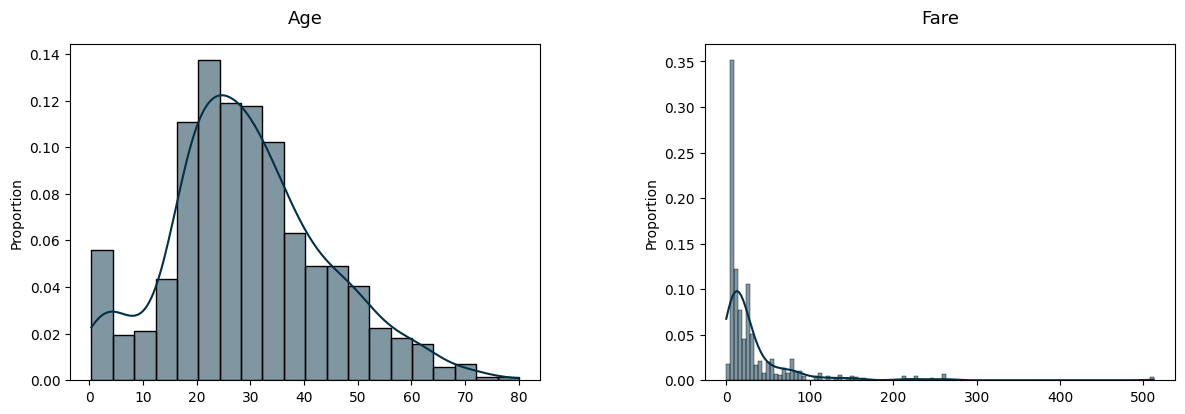

In [ ]:
analysis_plots(data=data, features=numplots_features, kde=True, figsize=(20, 4))

In [ ]:
outlier_indexes, outlier_counts, total_outliers = check_outliers(data=data, features=numplots_features)

There are 127 outliers in the dataset.

Number (percentage) of outliers per feature: 

Age: 11 (1.23)%
Fare: 116 (13.02)%


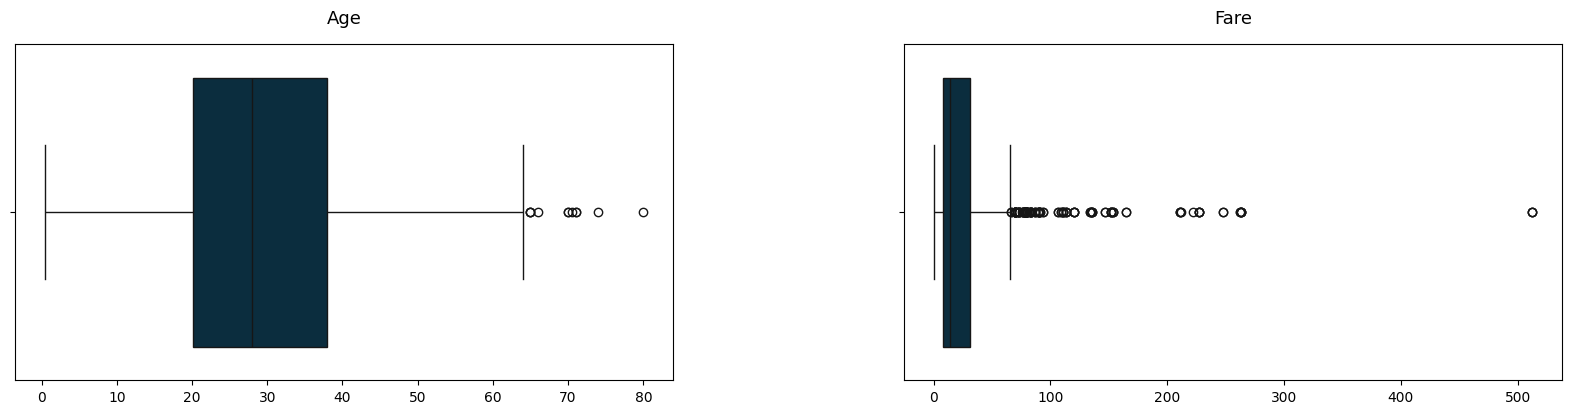

In [ ]:
analysis_plots(data=data, features=numplots_features, outliers=True, figsize=(28, 4))

In [ ]:
all_outliers = []

for feature in outlier_indexes:
    all_outliers.extend(outlier_indexes[feature])

all_outliers = list(set(all_outliers))
data_clean = data.drop(index=all_outliers)

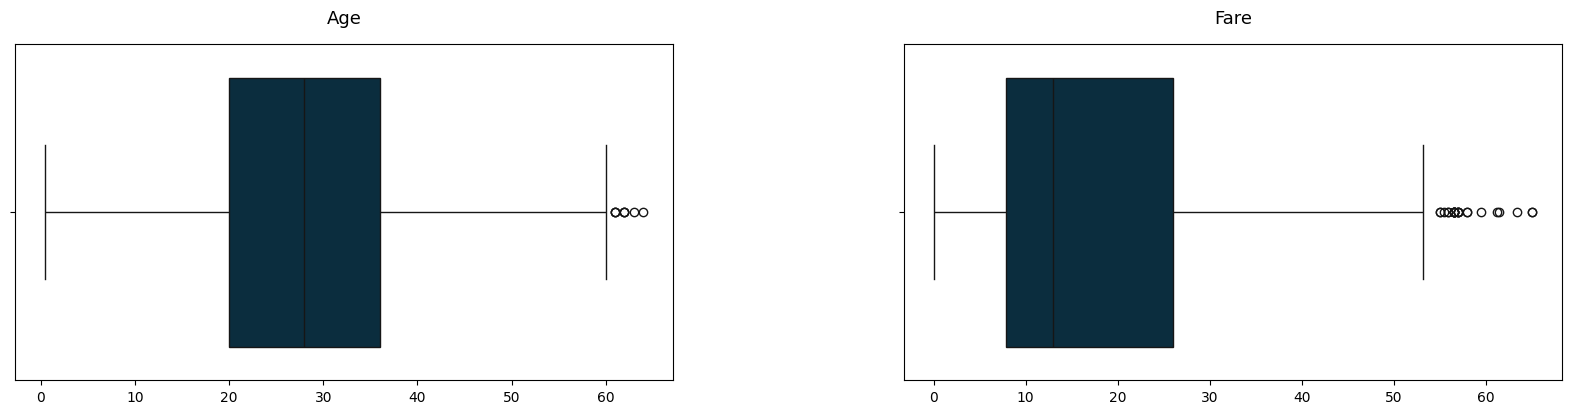

In [ ]:
analysis_plots(data=data_clean, features=numplots_features, outliers=True, figsize=(28, 4))

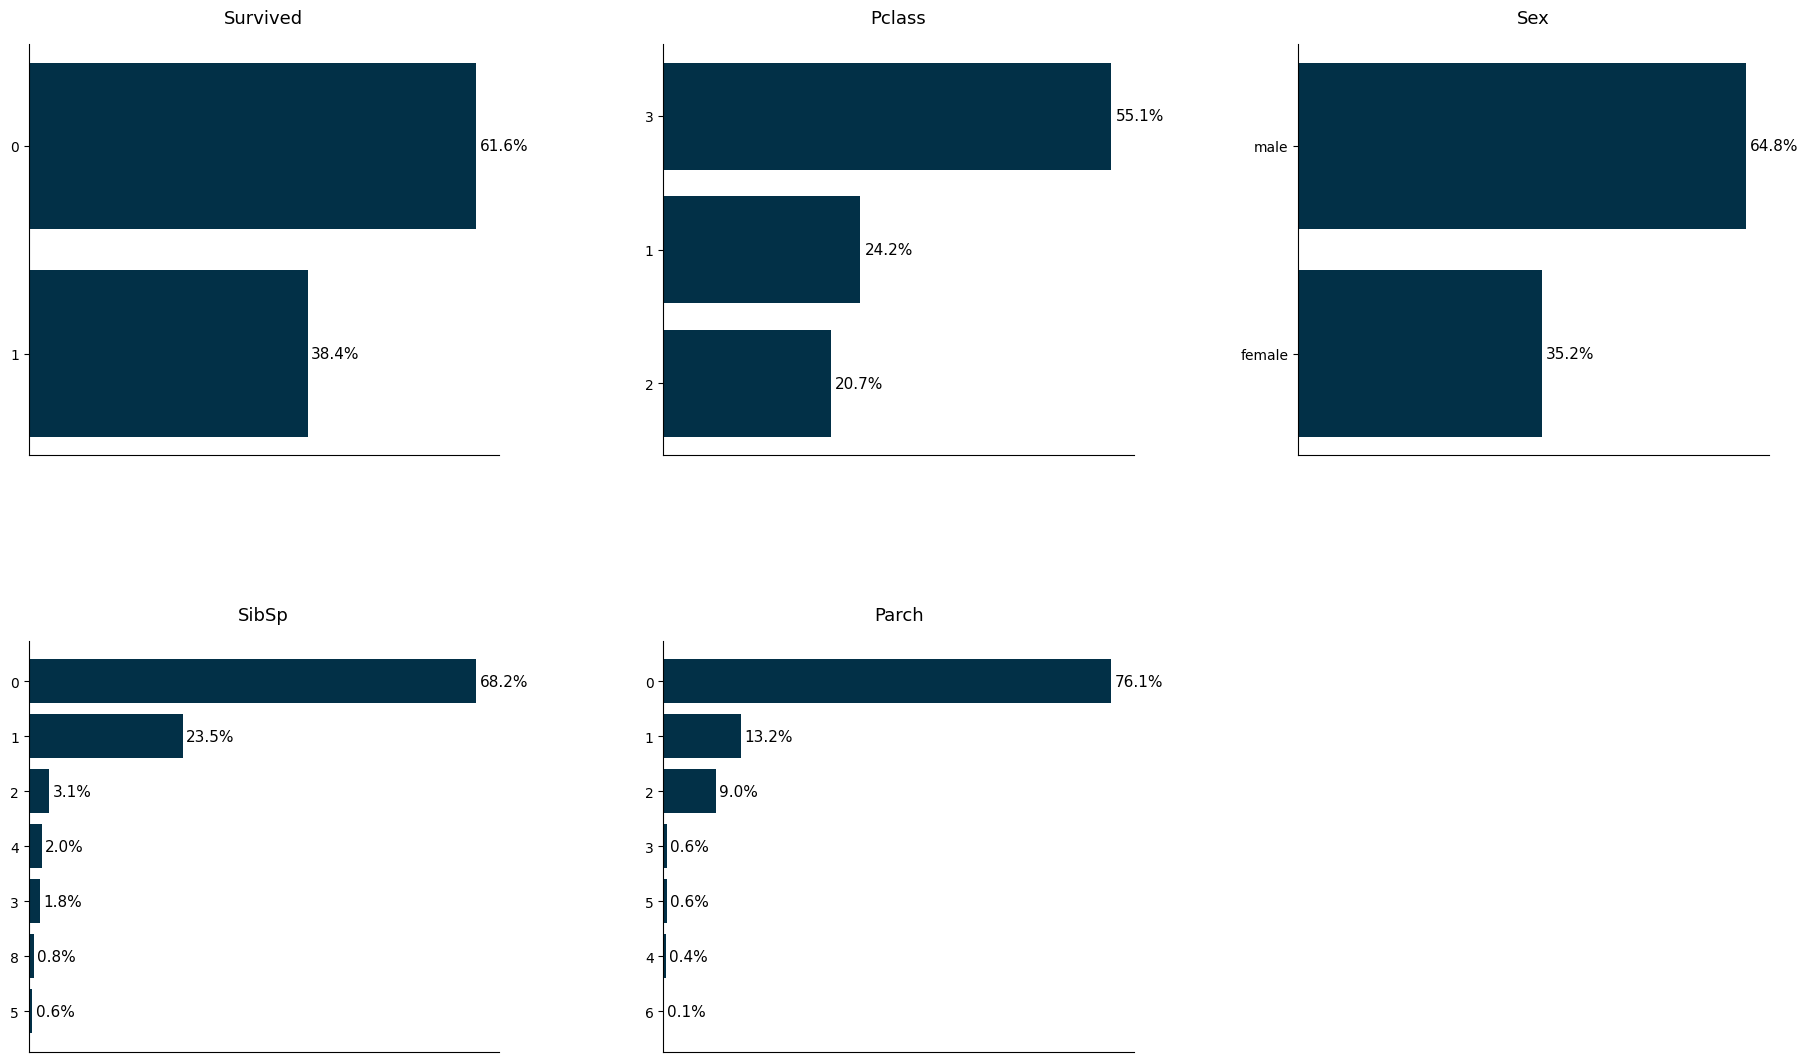

In [ ]:
# Suas features discretas
discrete_features = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch']

# Chamar a função (agora sem erros de layout!)
analysis_plots(data=data, features=discrete_features, barplot=True, figsize=(20, 12))

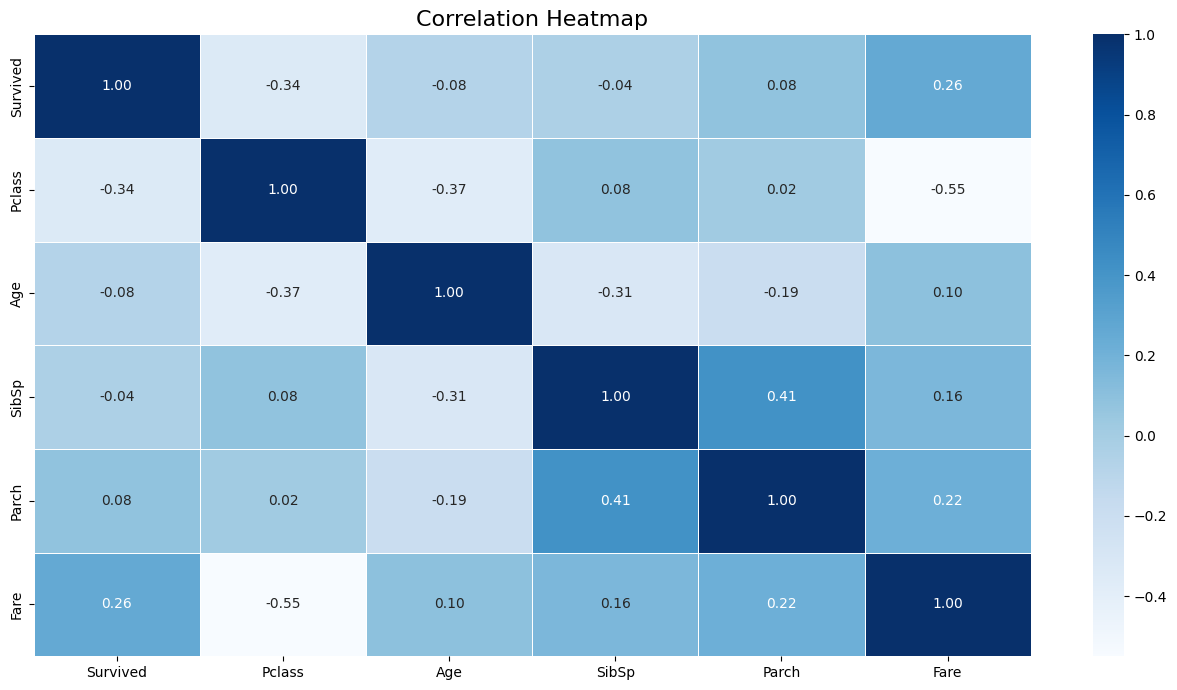

In [ ]:
# Colunas numéricas para correlação
numeric_columns = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# Computa a matriz de correlação
correlation_matrix = data[numeric_columns].corr()

# Cria heatmap para visualizar as correlações
plt.figure(figsize=(13, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)

# Ajusta layout e exibe o plot
plt.title('Correlation Heatmap', size=16)
plt.tight_layout()
plt.show()

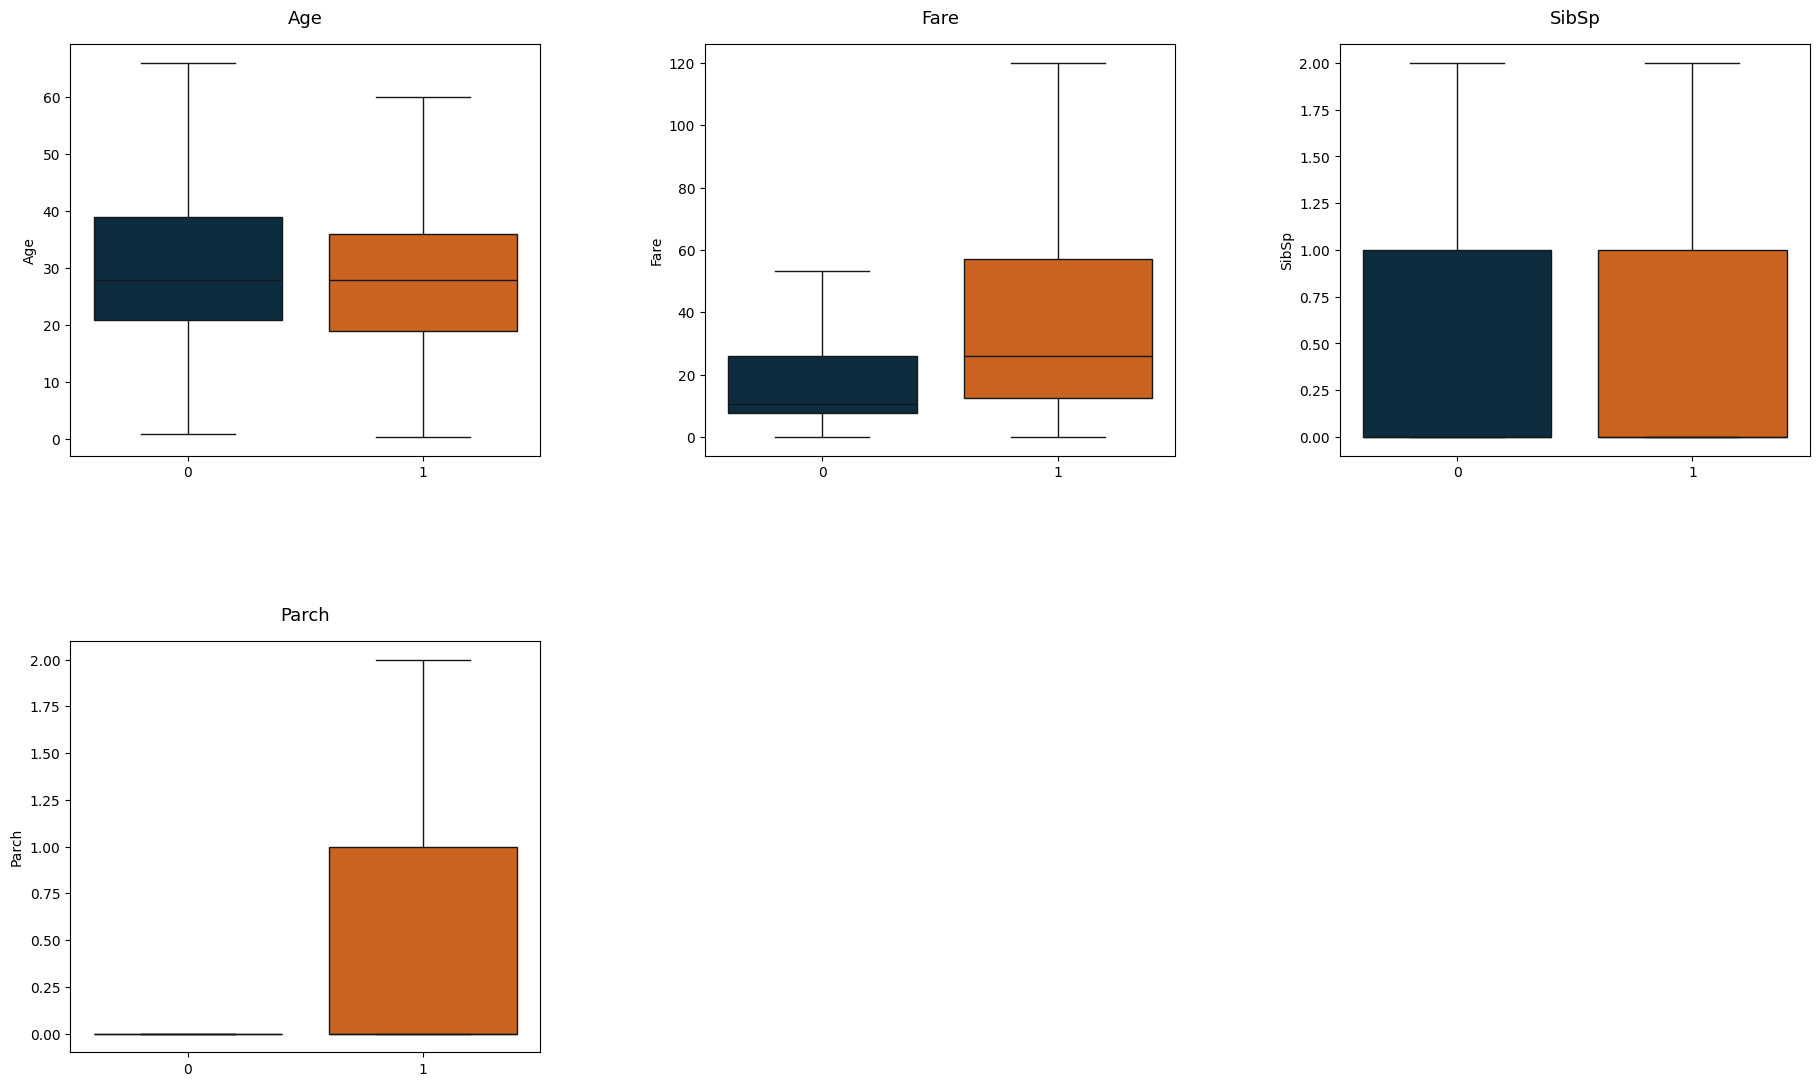

In [ ]:
# Lista das variáveis para plotar
features = ['Age', 'Fare', 'SibSp', 'Parch']

# Usando SUA função (muito mais limpo!)
analysis_plots(
    data=data,
    features=features,
    boxplot=True,           # Ativa boxplots
    boxplot_x='Survived',   # Variável para comparar no eixo X
    outliers=False,         # Não mostrar outliers (opcional)
    figsize=(20, 12)
)

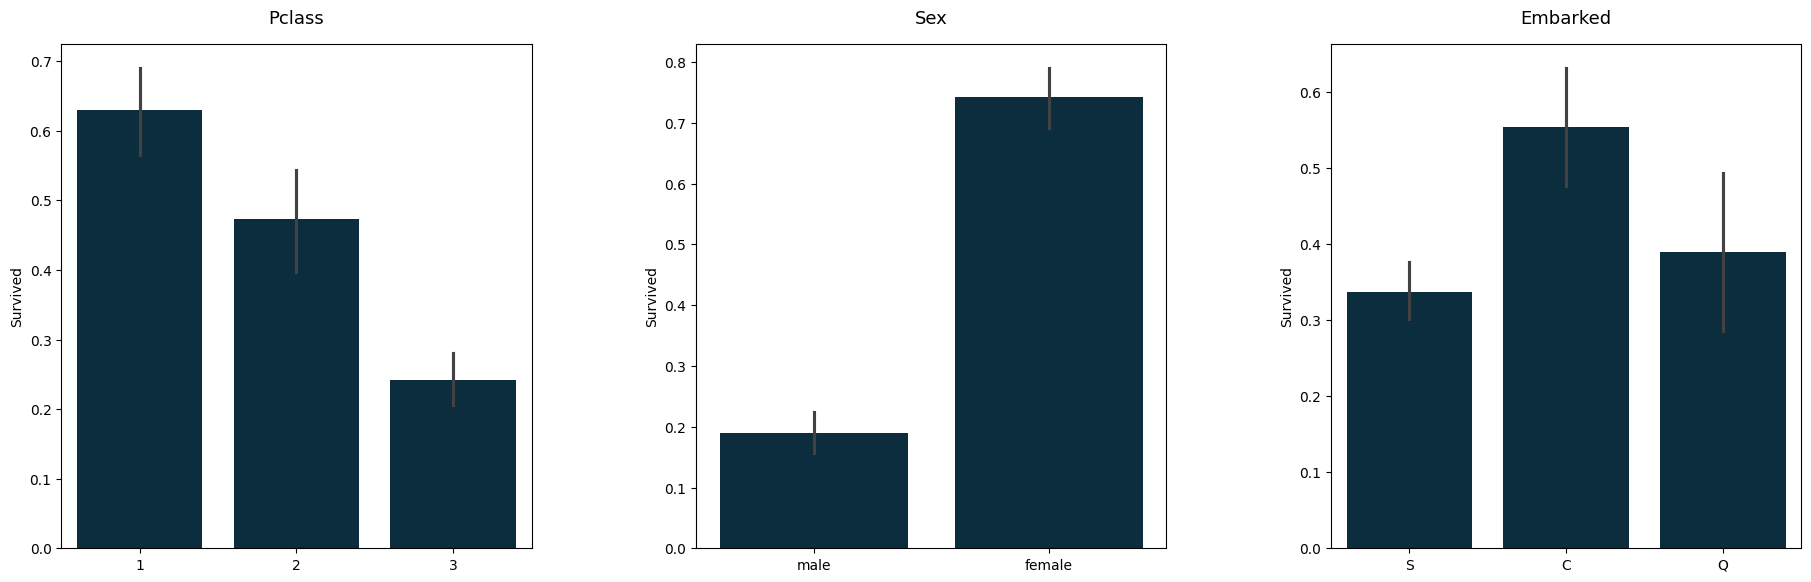

In [ ]:
analysis_plots(
    data=data,
    features=['Pclass','Sex','Embarked'],
    barplot=True,
    target='Survived',
    figsize=(20, 6)
)

### **MODELAGEM**

In [ ]:
# 1. Preparar dados (usando seu código existente do notebook)
df = data_clean.copy()
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

target = 'Survived'
X = df.drop(columns=target)
y = df[target]

# 2. Split Hold-Out (80% treino, 20% teste)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Train survival rate: {y_train.mean():.4f}")
print(f"Test survival rate: {y_val.mean():.4f}")

Train set: 612 samples (80.0%)
Test set: 153 samples (20.0%)
Train survival rate: 0.3431
Test survival rate: 0.3399


In [ ]:
# 3. Pré-processamento
X_train_proc, X_val_proc, transformers = preprocess_data_holdout(X_train, X_val)

Colunas após pré-processamento: ['Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass_1', 'Pclass_2', 'Pclass_3']
Shape X_train_proc: (612, 11)
Shape X_val_proc: (153, 11)


In [ ]:
X_train_proc.head()

,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
51,1,-0.580823,0,0,0.120000,0.0,0.0,1.0,0.0,0.0,1.0
67,1,-0.743584,0,0,0.125512,0.0,0.0,1.0,0.0,0.0,1.0
98,0,0.477124,0,1,0.353846,0.0,0.0,1.0,0.0,1.0,0.0
408,1,-0.580823,0,0,0.119615,0.0,0.0,1.0,0.0,0.0,1.0
57,1,0.029531,0,0,0.111218,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
transformers

{'age_imputer': SimpleImputer(strategy='median'),
 'age_scaler': StandardScaler(),
 'fare_imputer': SimpleImputer(strategy='median'),
 'fare_scaler': MinMaxScaler(),
 'sex_imputer': SimpleImputer(strategy='most_frequent'),
 'sex_encoder': OrdinalEncoder(categories=[['female', 'male']], dtype=<class 'int'>),
 'embarked_imputer': SimpleImputer(strategy='most_frequent'),
 'embarked_encoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 'embarked_cols': ['Embarked_C', 'Embarked_Q', 'Embarked_S'],
 'pclass_encoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 'pclass_cols': ['Pclass_1', 'Pclass_2', 'Pclass_3']}

In [ ]:
# 4. Definir modelos
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'SVC': SVC(probability=True, kernel='rbf', random_state=42)
}

# 5. Treinar e Avaliar (Captura os retornos)
trained_models, results = fit_models(
    models,
    X_train_proc,
    y_train,
    X_val_proc,
    y_val
)

# Visualiza resultados
results

,model,train_accuracy,val_accuracy,overfitting_gap,training_time
0,GradientBoosting,0.905229,0.843137,0.062092,0.852470
1,RandomForest,0.980392,0.810458,0.169935,0.558626
2,LogisticRegression,0.795752,0.803922,-0.008170,0.018897
3,SVC,0.841503,0.797386,0.044118,0.281124


In [ ]:
print_classification_reports(trained_models, X_val_proc, y_val)


LogisticRegression
----------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       101
           1       0.76      0.62      0.68        52

    accuracy                           0.80       153
   macro avg       0.79      0.76      0.77       153
weighted avg       0.80      0.80      0.80       153


RandomForest
----------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       101
           1       0.78      0.62      0.69        52

    accuracy                           0.81       153
   macro avg       0.80      0.76      0.78       153
weighted avg       0.81      0.81      0.80       153


GradientBoosting
----------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       101
           1       0.91      0.60      0.72        52

    acc

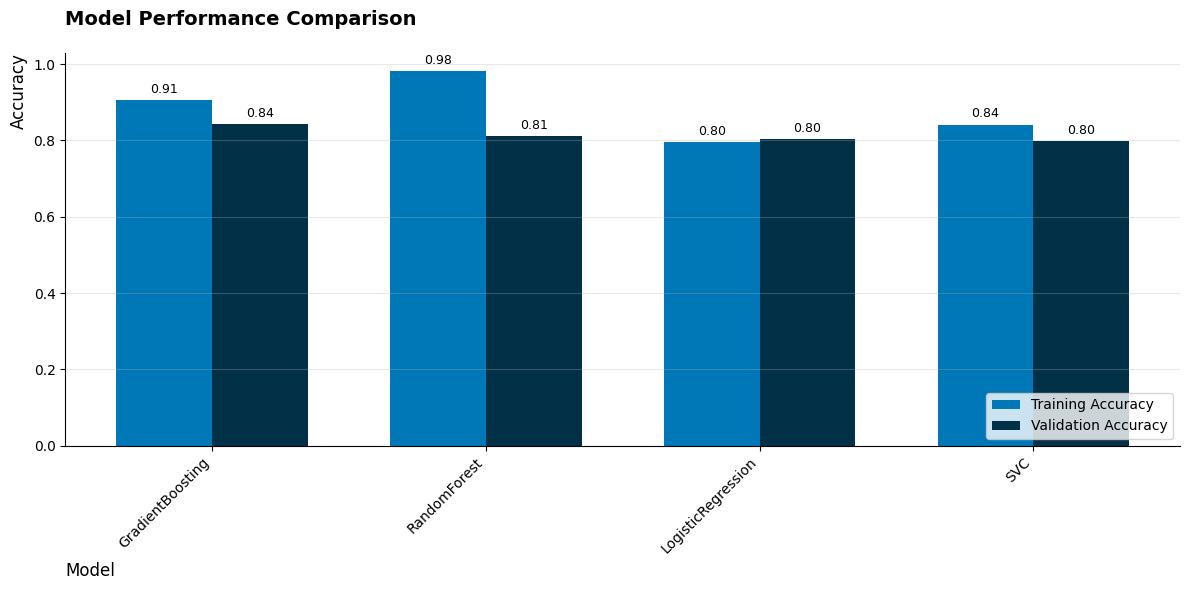

In [ ]:
plot_performance(results)

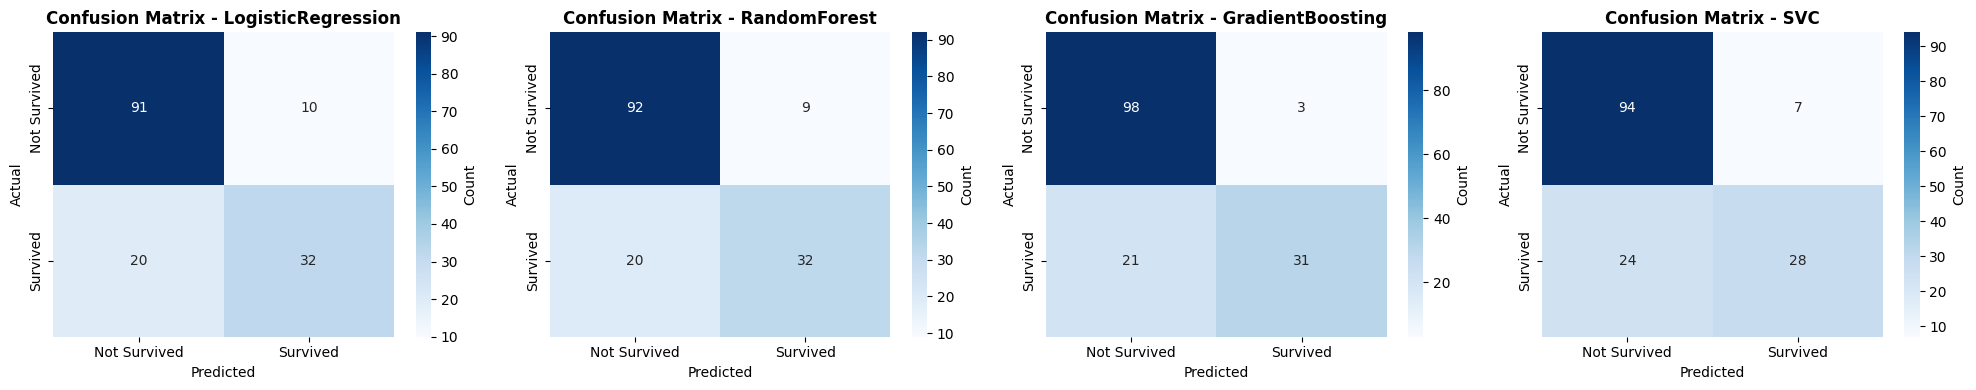

In [ ]:
plot_confusion_matrices(trained_models, X_val_proc, y_val)

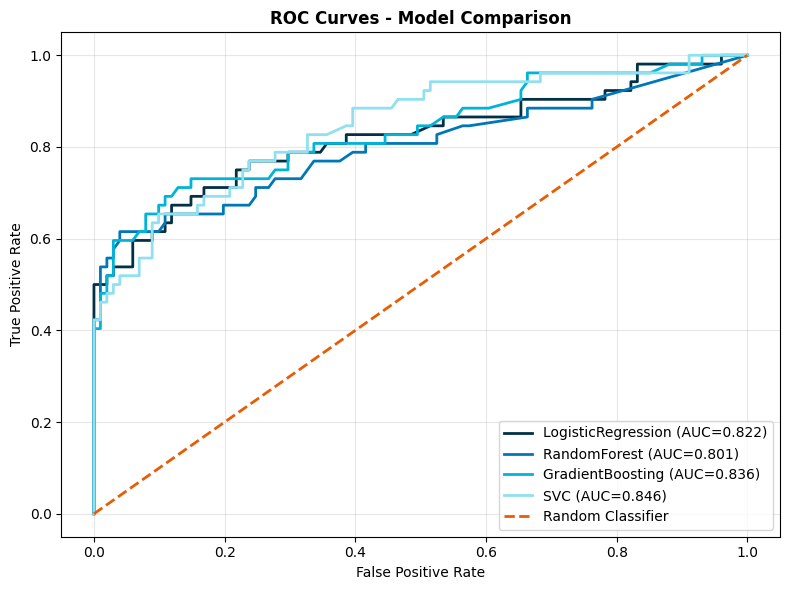

In [ ]:
plot_roc_curves(trained_models, X_val_proc, y_val)